Final analytical notebook. Run after Notebook 04 and save in Google Colab.


# 05 | Explainability and Power BI Preparation

Notebook 03 selected LightGBM, and Notebook 04 produced the final 28-day forecast. This notebook prepares the results for Power BI and checks that the exported tables are complete.

It also answers two practical questions:

1. Which features did LightGBM rely on most?
2. Which category-store forecasts should receive more attention because their historical errors were relatively high?

Power BI will not retrain the model. Python produces the forecasts and evaluation results, while Power BI will be used to filter, compare and present them.


## 1. Load the saved results

I load the forecasts, evaluation results, selection decision, feature importance and leakage checks produced by the earlier notebooks. Dashboard design does not change which model was selected.


In [15]:
from pathlib import Path
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/MSc_Dissertation_Forecasting_Final")
except ImportError:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    PROJECT_ROOT = next(
        (path for path in candidates if (path / "src").is_dir()),
        Path.cwd().resolve(),
    )

if not (PROJECT_ROOT / "src").is_dir():
    raise FileNotFoundError(
        f"Project source folder not found under {PROJECT_ROOT}."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.project_paths import ProjectPaths

PATHS = ProjectPaths(PROJECT_ROOT)
PATHS.ensure_output_directories()

import subprocess

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

metrics = pd.read_csv(PATHS.metrics / "forecast_metrics_all_models.csv")
selection = pd.read_csv(PATHS.metrics / "model_selection.csv")
importance = pd.read_csv(PATHS.metrics / "lightgbm_feature_importance.csv")
leakage = pd.read_csv(PATHS.metrics / "lightgbm_leakage_test.csv")
monitoring = pd.read_csv(PATHS.powerbi / "fact_forecast_monitoring.csv")
forecasts = pd.read_csv(
    PATHS.powerbi / "fact_forecasts_all_models.csv",
    parse_dates=["origin_date", "forecast_date"],
)

display(selection)
assert selection.loc[0, "selected_model"] == "global_lightgbm_recursive"
assert bool(selection.loc[0, "lightgbm_selected"])
assert leakage["passed"].all()
assert leakage["n_predictions"].eq(30 * 28).all()
assert leakage["maximum_absolute_difference"].eq(0).all()
print(f"Forecast rows available for dashboard preparation: {len(forecasts):,}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,selected_model,lightgbm_lower_rmsse_than_both_baselines,lightgbm_series_wins_vs_seasonal_naive,lightgbm_series_wins_vs_holt_winters,required_series_wins,lightgbm_selected,rationale
0,global_lightgbm_recursive,True,29,19,16,True,LightGBM passed the pre-specified complexity g...


Forecast rows available for dashboard preparation: 10,080


## 2. Examine feature importance

LightGBM gain importance measures how much each feature helped the model reduce prediction error when building its trees. I calculate importance in each fold and then average it.

This shows which variables were useful for prediction. It does not show that those variables caused demand to change.


,feature,mean_gain_share,minimum_gain_share,maximum_gain_share,fold_sd,mean_gain_percent
5,lag_28,0.3914,0.3792,0.4101,0.0149,39.1434
6,lag_7,0.2313,0.2102,0.2614,0.0237,23.1265
9,rolling_mean_7,0.1668,0.1536,0.1816,0.0139,16.6813
3,lag_1,0.1518,0.1402,0.1602,0.0101,15.1765
4,lag_14,0.0365,0.0327,0.0419,0.0040,3.6497
10,snap,0.0067,0.0067,0.0068,0.0001,0.6738
13,weekday,0.0050,0.0049,0.0050,0.0001,0.4980
7,month,0.0031,0.0029,0.0031,0.0001,0.3063
8,rolling_mean_28,0.0030,0.0026,0.0032,0.0003,0.2952
1,event_type_1,0.0018,0.0017,0.0019,0.0001,0.1810


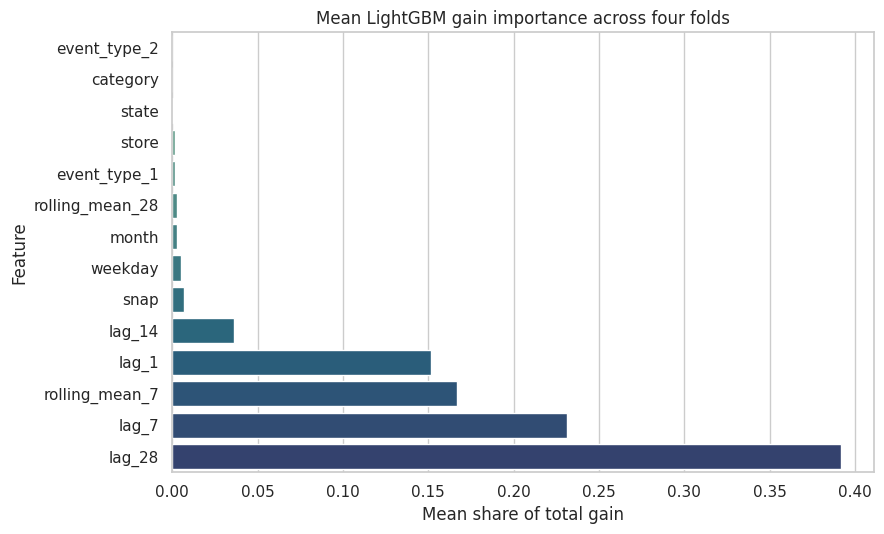

In [16]:
importance_summary = (
    importance.groupby("feature", observed=True)["gain_share"]
    .agg(
        mean_gain_share="mean",
        minimum_gain_share="min",
        maximum_gain_share="max",
        fold_sd="std",
    )
    .reset_index()
    .sort_values("mean_gain_share", ascending=False)
)
importance_summary["mean_gain_percent"] = importance_summary["mean_gain_share"] * 100
display(importance_summary)

fig, ax = plt.subplots(figsize=(9, 5.5))
plot_importance = importance_summary.sort_values("mean_gain_share", ascending=True)
sns.barplot(
    data=plot_importance,
    x="mean_gain_share",
    y="feature",
    hue="feature",
    legend=False,
    palette="crest",
    ax=ax,
)
ax.set(
    title="Mean LightGBM gain importance across four folds",
    xlabel="Mean share of total gain",
    ylabel="Feature",
)
fig.tight_layout()
display(fig)
plt.close(fig)


The model relies mainly on past demand. The 28-day lag is most important, followed by the seven-day lag, seven-day rolling average and one-day lag. This is consistent with recurring weekly and four-week patterns.

Calendar and SNAP variables have lower overall importance, but this does not mean they are irrelevant on every date. I retain gain importance because it can be calculated consistently across all four fold models. It should not be interpreted as evidence of causation.

## 3. Identify forecasts for review

A manager should not need to inspect every historical forecast. I rank the 30 category-store series using their past LightGBM errors so that weaker series can be reviewed first.

The labels are monitoring priorities only. They do not automatically recommend stock or supplier changes.


,series_id,mean_fold_rmsse,maximum_fold_rmsse,pooled_series_wape,folds,monitoring_priority
0,HOUSEHOLD_WI_2,1.2312,1.8637,0.1449,4,High review
1,HOBBIES_CA_4,0.8857,0.9517,0.1427,4,High review
2,FOODS_CA_2,0.8458,1.4477,0.0853,4,High review
3,FOODS_WI_2,0.8312,0.9684,0.0980,4,High review
4,HOBBIES_WI_2,0.8217,0.9259,0.1423,4,High review
5,HOUSEHOLD_CA_4,0.8156,0.9494,0.0807,4,High review
6,HOBBIES_TX_3,0.7800,0.8961,0.1104,4,High review
7,HOUSEHOLD_TX_3,0.7189,0.8360,0.0859,4,High review
8,HOUSEHOLD_CA_2,0.7125,0.9141,0.1139,4,High review
9,HOBBIES_CA_2,0.7040,0.8172,0.1326,4,High review


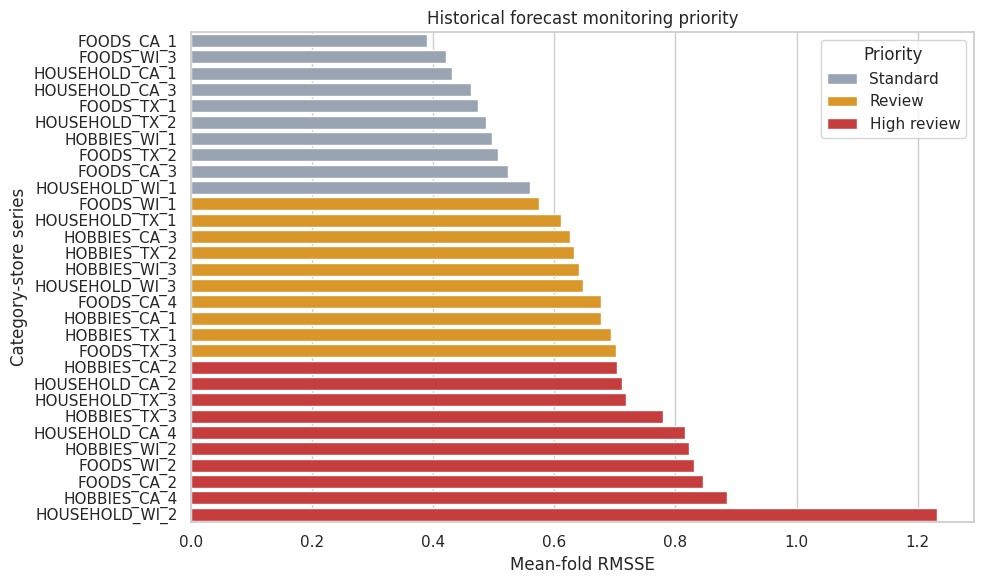

In [17]:
exception_summary = (
    monitoring[
        [
            "series_id",
            "historical_mean_rmsse",
            "historical_max_fold_rmsse",
            "historical_wape",
            "evaluated_folds",
            "monitoring_priority",
        ]
    ]
    .rename(
        columns={
            "historical_mean_rmsse": "mean_fold_rmsse",
            "historical_max_fold_rmsse": "maximum_fold_rmsse",
            "historical_wape": "pooled_series_wape",
            "evaluated_folds": "folds",
        }
    )
    .sort_values(["mean_fold_rmsse", "maximum_fold_rmsse"], ascending=False)
)

priority_counts = exception_summary["monitoring_priority"].value_counts()
assert priority_counts.to_dict() == {
    "High review": 10,
    "Review": 10,
    "Standard": 10,
}
display(exception_summary)

fig, ax = plt.subplots(figsize=(10, 6))
plot_exceptions = exception_summary.sort_values("mean_fold_rmsse", ascending=True)
sns.barplot(
    data=plot_exceptions,
    x="mean_fold_rmsse",
    y="series_id",
    hue="monitoring_priority",
    palette={
        "Standard": "#94A3B8",
        "Review": "#F59E0B",
        "High review": "#DC2626",
    },
    ax=ax,
)
ax.set(
    title="Historical forecast monitoring priority",
    xlabel="Mean-fold RMSSE",
    ylabel="Category-store series",
)
ax.legend(title="Priority")
fig.tight_layout()
display(fig)
plt.close(fig)


The three labels divide the 30 series into relative terciles of historical mean-fold RMSSE. They are review priorities, not universal business-risk thresholds. A real organisation would set its own limits based on service risk and forecast-error tolerance.

## 4. Create the Power BI tables

The export script creates a star-schema structure for the public forecasting case: dimensions describe dates, category-store series, and models; fact tables contain demand, forecasts, metrics, model selection, feature importance, and leakage validation. The dissertation's separate operational demonstrator is intentionally excluded because its redistribution licence is unclear.


In [ ]:
calendar_path = PATHS.m5_file("calendar.csv")

command = [
    sys.executable,
    str(PROJECT_ROOT / "scripts" / "export_powerbi.py"),
    "--project-root", str(PROJECT_ROOT),
    "--calendar", str(calendar_path),
]
completed = subprocess.run(command, check=True, capture_output=True, text=True)
print(completed.stdout)


Running the export again from the same inputs produces the same tables. The raw datasets remain in the private project folder and are not included in GitHub.

## 5. Check the exported tables

Before opening Power BI, I check row counts, missing values, unique keys and whether fact-table keys match the dimensions. This helps identify data problems before building visuals or DAX measures.


In [ ]:
powerbi_dir = PATHS.powerbi
manifest = pd.read_csv(powerbi_dir / "refresh_manifest.csv")
display(manifest)

dim_date = pd.read_csv(powerbi_dir / "dim_date.csv")
dim_series = pd.read_csv(powerbi_dir / "dim_series.csv")
dim_model = pd.read_csv(powerbi_dir / "dim_model.csv")
fact_actual = pd.read_csv(powerbi_dir / "fact_actual_demand.csv")
fact_forecast = pd.read_csv(powerbi_dir / "fact_forecast_results.csv")
fact_metrics = pd.read_csv(powerbi_dir / "fact_forecast_metrics.csv")
fact_forward = pd.read_csv(powerbi_dir / "fact_forward_forecast.csv")
fact_category_forward = pd.read_csv(powerbi_dir / "fact_category_forward_forecast.csv")
fact_monitoring = pd.read_csv(powerbi_dir / "fact_forecast_monitoring.csv")

checks = []
def record_check(name, passed, detail):
    checks.append({"validation_check": name, "passed": bool(passed), "detail": detail})

record_check(
    "Date dimension key is unique",
    dim_date["date"].is_unique,
    f"{len(dim_date):,} dates",
)
record_check(
    "Series dimension key is unique",
    dim_series["series_id"].is_unique,
    f"{len(dim_series):,} series",
)
record_check(
    "Model dimension key is unique",
    dim_model["model"].is_unique,
    f"{len(dim_model):,} models",
)
record_check(
    "Actual demand key is unique",
    not fact_actual.duplicated(["series_id", "date"]).any(),
    f"{len(fact_actual):,} rows",
)
record_check(
    "Forecast key is unique",
    not fact_forecast.duplicated(
        ["model", "fold_id", "series_id", "forecast_date"]
    ).any(),
    f"{len(fact_forecast):,} rows",
)
record_check(
    "Forecast series keys resolve",
    fact_forecast["series_id"].isin(dim_series["series_id"]).all(),
    "All forecast series exist in dim_series",
)
record_check(
    "Forecast model keys resolve",
    fact_forecast["model"].isin(dim_model["model"]).all(),
    "All forecast models exist in dim_model",
)
record_check(
    "Forecast dates resolve",
    fact_forecast["forecast_date"].isin(dim_date["date"]).all(),
    "All forecast dates exist in dim_date",
)
record_check(
    "Forward row count is correct",
    len(fact_forward) == 30 * 28,
    f"{len(fact_forward):,} rows",
)
record_check(
    "Forward key is unique",
    not fact_forward.duplicated(["series_id", "forecast_date"]).any(),
    "One row per series-date",
)
record_check(
    "Forward series keys resolve",
    fact_forward["series_id"].isin(dim_series["series_id"]).all(),
    "All forward series exist in dim_series",
)
record_check(
    "Forward dates resolve",
    fact_forward["forecast_date"].isin(dim_date["date"]).all(),
    "All forward dates exist in dim_date",
)
record_check(
    "Category total row count is correct",
    len(fact_category_forward) == 3 * 28,
    f"{len(fact_category_forward):,} rows",
)
record_check(
    "Monitoring profile covers all series",
    fact_monitoring["series_id"].nunique() == 30,
    f"{len(fact_monitoring):,} rows",
)
record_check(
    "No manifest missing cells",
    manifest["missing_cells"].eq(0).all(),
    f"{manifest['missing_cells'].sum()} missing cells",
)

validation_results = pd.DataFrame(checks)
display(validation_results)
assert validation_results["passed"].all()


### Dashboard handoff map

The table below records which exported analytical output supports each implemented dashboard page. This makes the trace from Python calculation to Power BI visual explicit.


In [ ]:
handoff_rows = [
    ("fact_actual_demand", len(fact_actual), "1. Executive overview; 2. Demand & Exceptions", "Observed category-store demand"),
    ("fact_forward_forecast", len(fact_forward), "1. Executive overview", "28-day category-store forecast and monitoring ranges"),
    ("fact_category_forward_forecast", len(fact_category_forward), "1. Executive overview", "28-day category totals"),
    ("fact_forecast_results", len(fact_forecast), "2. Demand & Exceptions; 3. Forecast Performance", "Historical actuals, forecasts and errors"),
    ("fact_forecast_metrics", len(fact_metrics), "3. Forecast Performance", "Overall, fold, series-fold and horizon metrics"),
    ("fact_forecast_monitoring", len(fact_monitoring), "1. Executive overview; 2. Demand & Exceptions", "Historical reliability and relative review priority"),
    ("fact_model_selection", len(pd.read_csv(powerbi_dir / "fact_model_selection.csv")), "1. Executive overview; 4. Governance and Provenance", "Pre-specified model-selection decision"),
    ("fact_lightgbm_feature_importance", len(pd.read_csv(powerbi_dir / "fact_lightgbm_feature_importance.csv")), "4. Governance and Provenance", "Descriptive LightGBM feature reliance"),
    ("fact_leakage_validation", len(pd.read_csv(powerbi_dir / "fact_leakage_validation.csv")), "4. Governance and Provenance", "Post-origin masking-test evidence"),
]
dashboard_handoff = pd.DataFrame(
    handoff_rows, columns=["table", "rows", "dashboard_page", "role"]
)
display(dashboard_handoff)


## 6. Implemented Power BI model

The forecasting report uses one-to-many relationships from `dim_date`, `dim_series` and `dim_model` to the relevant M5 fact tables. The selection, feature-importance and masking tables are displayed as governed evidence tables.

The metrics table contains several scopes: overall, fold, series-fold and horizon band. Measures and visual filters must select the intended scope rather than add pre-calculated values together.

## 7. Dashboard calculation and interaction controls

- Overall RMSSE is the arithmetic mean of 120 series-fold RMSSE values.
- Pooled LightGBM WAPE is total absolute error divided by total actual demand across all 3,360 LightGBM backtest predictions.
- Mean series-level WAPE is the arithmetic mean of the 30 series' pooled four-fold WAPE values from `fact_forecast_monitoring`.
- `error` is actual minus forecast: positive values indicate under-forecasting and negative values indicate over-forecasting.
- Overall cards remain fixed at the complete four-fold result. The evaluation-fold slicer controls the series table, while the horizon-band slicer controls the horizon chart, preventing an invalid fold-by-band intersection from blanking the visuals.

The final DAX measures and any authored Power Query M must be exported from the completed Power BI file and inserted into the code appendix. They are not duplicated here because the Power BI file is the authoritative source for those expressions.


## 8. Implemented dashboard pages

### Page 1: Executive overview

- the separate 28-day forward forecast, selected model and pooled LightGBM backtest WAPE;
- recent observed demand, the forward path and descriptive empirical monitoring ranges;
- category totals and a visible note that the ranges are not prediction or confidence intervals and do not imply validated 80% future coverage.

### Page 2: Demand & Exceptions

- a category-store review queue using historical WAPE, bias direction, relative priority and review action;
- a selected-series comparison of actual demand, Global LightGBM and Holt-Winters;
- review support only: no automatic inventory, safety-stock or supplier decision.

### Page 3: Forecast Performance

- fixed overall RMSSE cards for LightGBM, Holt-Winters and seasonal-naive;
- horizon-band comparison, overall model comparison and series-level reliability;
- balanced interpretation: LightGBM was strongest overall, while Holt-Winters was better on 11 series and during days 22–28.

### Page 4: Governance and Provenance

- feature gain as descriptive reliance rather than causality;
- the frozen selection gate and four post-origin masking rows;
- 840 predictions and maximum absolute difference 0.0 in every fold, with the acceptance tolerance and leakage-control caveat shown explicitly.


In [ ]:
assert validation_results["passed"].all()
assert manifest["missing_cells"].eq(0).all()
print("NOTEBOOK 05 COMPLETED SUCCESSFULLY")
